
Research Question: How strongly do rating differences affect chess game outcomes?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WEB SCRAPING MY CHESS.COM GAMES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Scraping data for: op_michael
Found 64 months of game history

Scraping Summary: 12630 rated games kept
Saved to: my_chess_games_scraped.csv

FILTER TO RAPID AND BLITZ ONLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Rapid + Blitz games: 5,482

LOADING AND CLEANING LICHESS DATASET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Loaded 20,058 Lichess games
Cleaned: 16,155 games

FIGURE 1 - OUTCOME COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


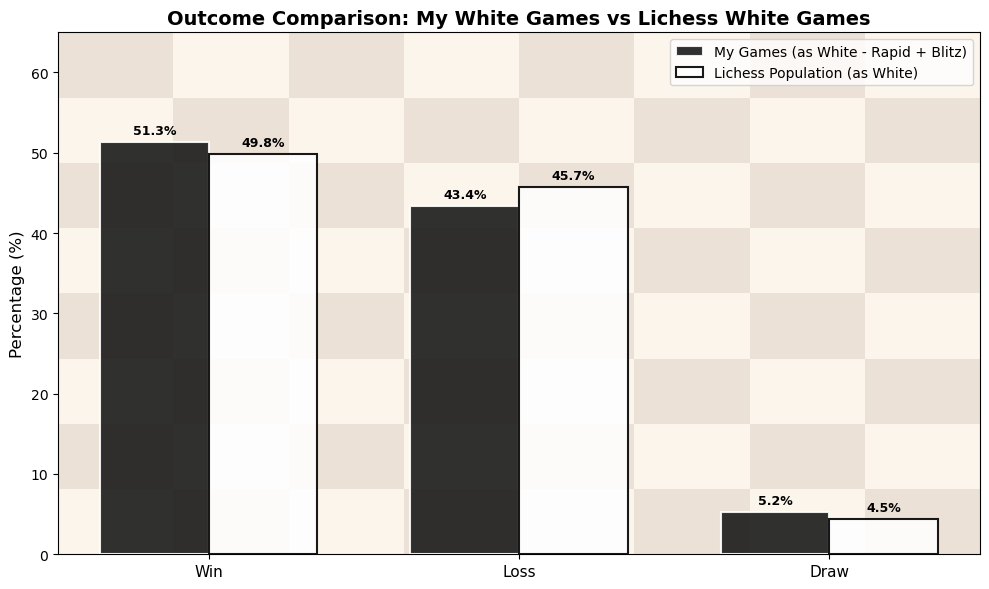

Figure 1 saved

FIGURE 2 - MY WIN PROBABILITY vs RATING DIFFERENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


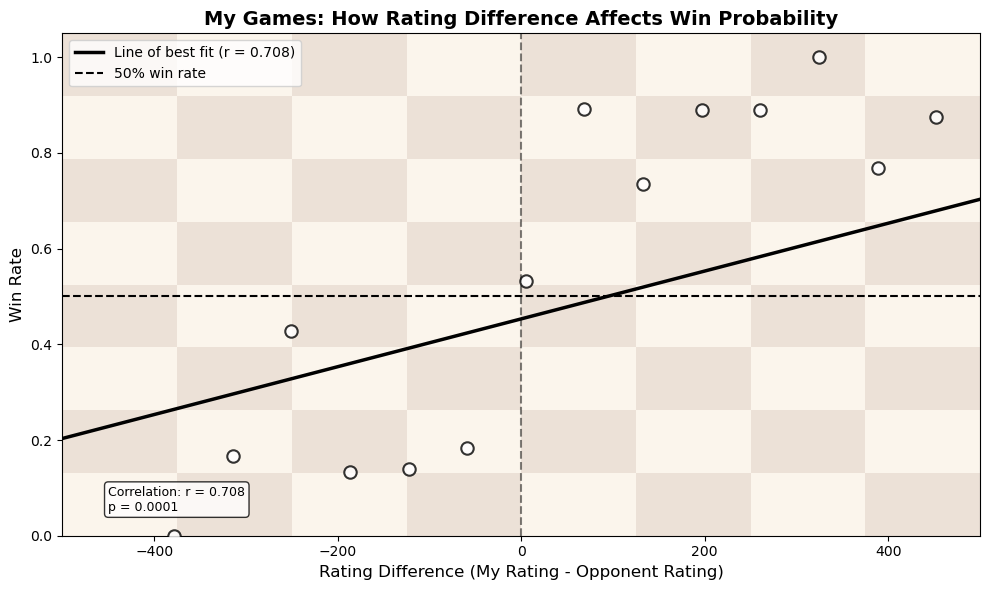

Figure 2 saved

FIGURE 3 - LICHESS POPULATION WIN PROBABILITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


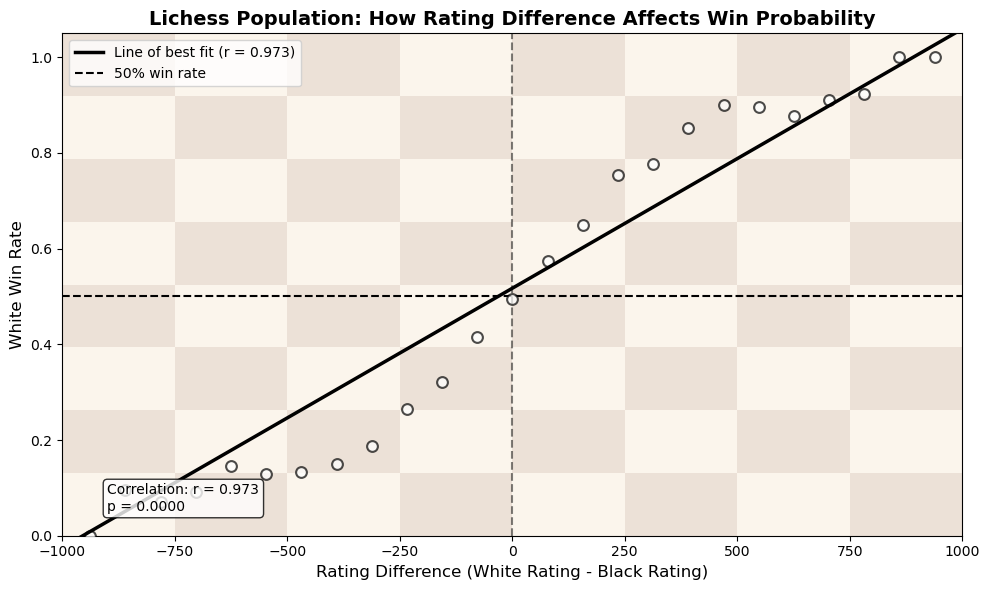

Figure 3 saved

LOGISTIC REGRESSION - LICHESS DATA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0252      0.017     -1.491      0.136      -0.058       0.008
rating_diff     0.0043      0.000     41.850      0.000       0.004       0.004

Pseudo R-squared: 0.1072

LOGISTIC REGRESSION - MY DATA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FIGURE 4 - LICHESS LOGISTIC CURVE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


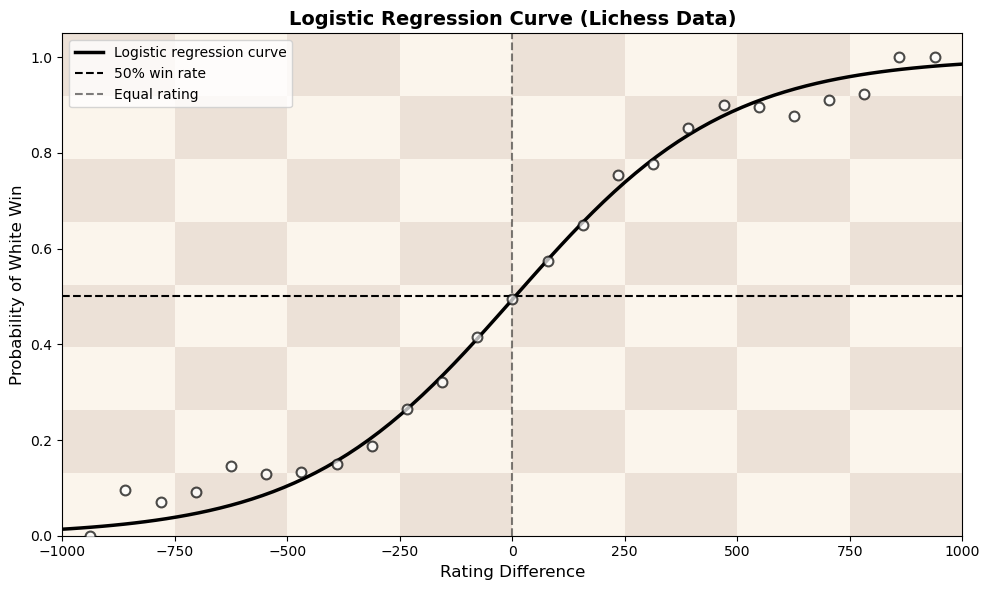

Figure 4 saved



FIGURE 5 - ROC CURVE COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


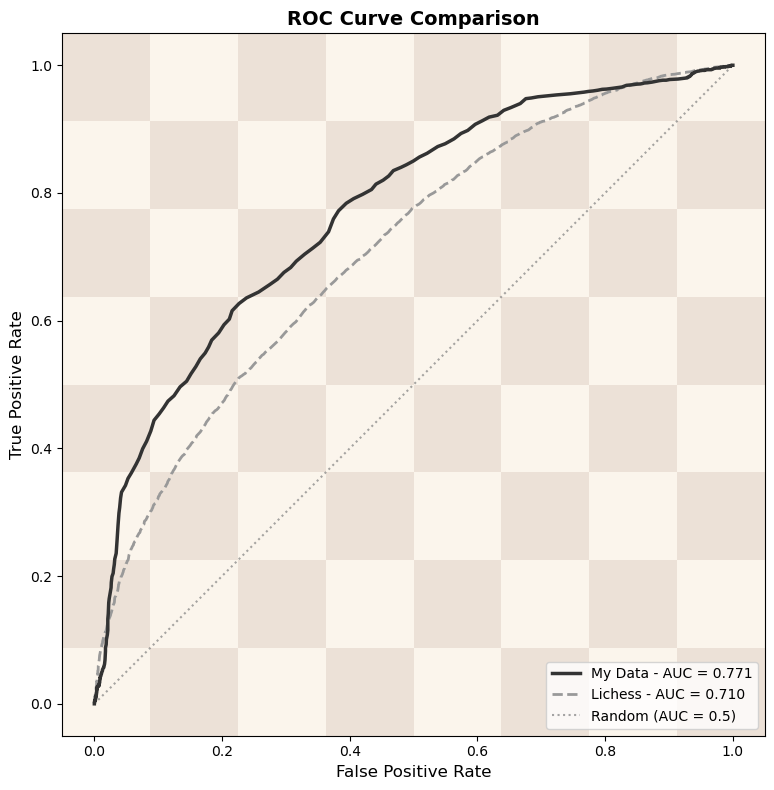

In [1]:
"""
BEE2041 Empirical Project
Research Question: How strongly do rating differences affect chess game outcomes?
"""

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import time
import re
from datetime import datetime
from sklearn.metrics import roc_auc_score, roc_curve
from scipy import stats
from matplotlib.patches import Rectangle

# PRINT FORMATTING FUNCTIONS

def print_underline(title, width=80):
    print(f"\n{title}")
    print("━" * width)

# CHESSBOARD BACKGROUND FUNCTION

def add_chessboard_background(ax, alpha=0.25):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    board_size = 8
    square_width = (xmax - xmin) / board_size
    square_height = (ymax - ymin) / board_size
    for row in range(board_size):
        for col in range(board_size):
            x_pos = xmin + col * square_width
            y_pos = ymin + row * square_height
            if (row + col) % 2 == 0:
                color = '#f0d9b5'
            else:
                color = '#b58863'
            rect = Rectangle((x_pos, y_pos), square_width, square_height,
                           facecolor=color, edgecolor='none', alpha=alpha, zorder=0)
            ax.add_patch(rect)

# Colour scheme
COLOR_WHITE_BAR = '#ffffff'
COLOR_BLACK_BAR = '#1a1a1a'
COLOR_BEST_FIT_LINE = '#000000'
COLOR_WHITE_DOT = '#ffffff'
COLOR_MY_DATA = '#333333'
COLOR_LICHESS_DATA = '#999999'


print_underline("Research Question: How strongly do rating differences affect chess game outcomes?")
print_underline("WEB SCRAPING MY CHESS.COM GAMES")

def scrape_my_rated_games(username="op_michael"):
    print(f"\nScraping data for: {username}")
    url = f"https://api.chess.com/pub/player/{username}/games/archives"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    response = requests.get(url, headers=headers)
    archives = response.json()['archives']
    print(f"Found {len(archives)} months of game history")
    all_games = []
    rated_kept = 0
    for archive_url in archives:
        parts = archive_url.split('/')
        year = parts[-2]
        month = parts[-1]
        games_response = requests.get(archive_url, headers=headers)
        games = games_response.json()['games']
        for game in games:
            if not game.get('rated', False):
                continue
            if game.get('time_class', 'unknown') == 'daily':
                continue
            rated_kept += 1
            white = game['white']
            black = game['black']
            white_username = white.get('username', '')
            black_username = black.get('username', '')
            white_rating = white.get('rating', 1500)
            black_rating = black.get('rating', 1500)
            i_was_white = (white_username.lower() == username.lower())
            my_rating = white_rating if i_was_white else black_rating
            opponent_rating = black_rating if i_was_white else white_rating
            rating_diff = my_rating - opponent_rating
            pgn = game.get('pgn', '')
            termination = ''
            term_match = re.search(r'\[Termination "([^"]+)"\]', pgn)
            if term_match:
                termination = term_match.group(1)
            if 'Game drawn' in termination:
                my_result = 'draw'
            elif 'OP_Michael won' in termination:
                my_result = 'win'
            elif 'won' in termination:
                my_result = 'loss'
            else:
                winner = game.get('winner', 'draw')
                if winner == 'draw':
                    my_result = 'draw'
                elif (winner == 'white' and i_was_white) or (winner == 'black' and not i_was_white):
                    my_result = 'win'
                else:
                    my_result = 'loss'
            moves = pgn.split()
            move_numbers = [m for m in moves if m.replace('.', '').isdigit() and '.' in m]
            turn_count = len(move_numbers) if move_numbers else 0
            all_games.append({
                'date': datetime.fromtimestamp(game['end_time']).strftime('%Y-%m-%d'),
                'white_rating': white_rating,
                'black_rating': black_rating,
                'my_color': 'white' if i_was_white else 'black',
                'my_rating': my_rating,
                'opponent_rating': opponent_rating,
                'rating_diff': rating_diff,
                'my_result': my_result,
                'my_win': 1 if my_result == 'win' else 0,
                'time_class': game['time_class'],
                'turns': turn_count
            })
        time.sleep(0.3)
    df = pd.DataFrame(all_games)
    print(f"\nScraping Summary: {rated_kept} rated games kept")
    return df

df_my_all = scrape_my_rated_games("op_michael")
df_my_all.to_csv('my_chess_games_scraped.csv', index=False)
print(f"Saved to: my_chess_games_scraped.csv")

print_underline("FILTER TO RAPID AND BLITZ ONLY")

df_my = df_my_all[df_my_all['time_class'].isin(['rapid', 'blitz'])].copy()
print(f"Rapid + Blitz games: {len(df_my):,}")

print_underline("LOADING AND CLEANING LICHESS DATASET")

df_lichess = pd.read_csv('lichessgames.csv')
print(f"Loaded {len(df_lichess):,} Lichess games")

df_lichess = df_lichess[df_lichess['rated'] == True]
df_lichess['rating_diff'] = df_lichess['white_rating'] - df_lichess['black_rating']
df_lichess['white_win'] = (df_lichess['winner'] == 'white').astype(int)
df_lichess = df_lichess[df_lichess['winner'].isin(['white', 'black', 'draw'])]

lichess_wins = (df_lichess['winner'] == 'white').sum()
lichess_losses = (df_lichess['winner'] == 'black').sum()
lichess_draws = (df_lichess['winner'] == 'draw').sum()
total_lichess = len(df_lichess)

print(f"Cleaned: {total_lichess:,} games")

print_underline("FIGURE 1 - OUTCOME COMPARISON")

total_my_white = (df_my['my_color'] == 'white').sum()
my_white_wins = df_my[(df_my['my_color'] == 'white') & (df_my['my_result'] == 'win')].shape[0]
my_white_losses = df_my[(df_my['my_color'] == 'white') & (df_my['my_result'] == 'loss')].shape[0]
my_white_draws = df_my[(df_my['my_color'] == 'white') & (df_my['my_result'] == 'draw')].shape[0]

my_white_values = [my_white_wins/total_my_white*100, my_white_losses/total_my_white*100, my_white_draws/total_my_white*100]
lichess_values = [lichess_wins/total_lichess*100, lichess_losses/total_lichess*100, lichess_draws/total_lichess*100]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.35

bars1 = ax.bar(x - width/2, my_white_values, width, label='My Games (as White - Rapid + Blitz)', 
               color=COLOR_BLACK_BAR, alpha=0.9, edgecolor='white', linewidth=1.5, zorder=3)
bars2 = ax.bar(x + width/2, lichess_values, width, label='Lichess Population (as White)', 
               color=COLOR_WHITE_BAR, alpha=0.9, edgecolor='black', linewidth=1.5, zorder=3)

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Outcome Comparison: My White Games vs Lichess White Games', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Win', 'Loss', 'Draw'], fontsize=11)
ax.legend(loc='upper right')
ax.set_ylim(0, 65)
ax.set_facecolor('none')
add_chessboard_background(ax, alpha=0.25)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold', color='black')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('fig1_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1 saved")

print_underline("FIGURE 2 - MY WIN PROBABILITY vs RATING DIFFERENCE")

df_my['rating_bin'] = pd.cut(df_my['rating_diff'], bins=30)
win_rate_by_diff = df_my.groupby('rating_bin', observed=True)['my_win'].mean()
my_bin_centers = [(i.left + i.right)/2 for i in win_rate_by_diff.index]

slope, intercept, r_value, p_value, std_err = stats.linregress(my_bin_centers, win_rate_by_diff.values)
line_of_best_fit = slope * np.array(my_bin_centers) + intercept

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(my_bin_centers, win_rate_by_diff.values, alpha=0.8, 
           color=COLOR_WHITE_DOT, s=80, marker='o', edgecolor='black', linewidth=1.5, zorder=3)
ax.plot(my_bin_centers, line_of_best_fit, color=COLOR_BEST_FIT_LINE, linewidth=2.5, 
        label=f'Line of best fit (r = {r_value:.3f})', zorder=3)
ax.axhline(y=0.5, color=COLOR_BEST_FIT_LINE, linestyle='--', linewidth=1.5, label='50% win rate', zorder=2)
ax.axvline(x=0, color=COLOR_BEST_FIT_LINE, linestyle='--', alpha=0.5, linewidth=1.5, zorder=2)
ax.set_xlabel('Rating Difference (My Rating - Opponent Rating)', fontsize=12)
ax.set_ylabel('Win Rate', fontsize=12)
ax.set_title('My Games: How Rating Difference Affects Win Probability', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlim(-500, 500)
ax.set_facecolor('none')
add_chessboard_background(ax, alpha=0.25)
ax.legend(loc='upper left')
ax.annotate(f'Correlation: r = {r_value:.3f}\np = {p_value:.4f}', 
            xy=(0.05, 0.05), xycoords='axes fraction', fontsize=9, color='black',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.savefig('fig2_my_win_probability.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 2 saved")

print_underline("FIGURE 3 - LICHESS POPULATION WIN PROBABILITY")

df_lichess['rating_bin'] = pd.cut(df_lichess['rating_diff'], bins=30)
lichess_win_rate = df_lichess.groupby('rating_bin', observed=True)['white_win'].mean()
lichess_bin_centers = [(i.left + i.right)/2 for i in lichess_win_rate.index]

slope_l, intercept_l, r_value_l, p_value_l, std_err_l = stats.linregress(lichess_bin_centers, lichess_win_rate.values)
line_of_best_fit_l = slope_l * np.array(lichess_bin_centers) + intercept_l

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(lichess_bin_centers, lichess_win_rate.values, alpha=0.7, 
           color=COLOR_WHITE_DOT, s=60, marker='o', edgecolor='black', linewidth=1.5, zorder=3)
ax.plot(lichess_bin_centers, line_of_best_fit_l, color=COLOR_BEST_FIT_LINE, linewidth=2.5, 
        label=f'Line of best fit (r = {r_value_l:.3f})', zorder=3)
ax.axhline(y=0.5, color=COLOR_BEST_FIT_LINE, linestyle='--', linewidth=1.5, label='50% win rate', zorder=2)
ax.axvline(x=0, color=COLOR_BEST_FIT_LINE, linestyle='--', alpha=0.5, linewidth=1.5, zorder=2)
ax.set_xlabel('Rating Difference (White Rating - Black Rating)', fontsize=12)
ax.set_ylabel('White Win Rate', fontsize=12)
ax.set_title('Lichess Population: How Rating Difference Affects Win Probability', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlim(-1000, 1000)
ax.set_facecolor('none')
add_chessboard_background(ax, alpha=0.25)
ax.legend(loc='upper left')
ax.annotate(f'Correlation: r = {r_value_l:.3f}\np = {p_value_l:.4f}', 
            xy=(0.05, 0.05), xycoords='axes fraction', fontsize=10, color='black',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.savefig('fig3_lichess_win_probability.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3 saved")

print_underline("LOGISTIC REGRESSION - LICHESS DATA")

X_li = sm.add_constant(df_lichess[['rating_diff']])
y_li = df_lichess['white_win']

model_li = sm.Logit(y_li, X_li).fit(disp=0)
null_model_li = sm.Logit(y_li, np.ones(len(y_li))).fit(disp=0)
pseudo_r2_li = 1 - (model_li.llf / null_model_li.llf)

odds_ratio_100_li = np.exp(model_li.params['rating_diff'] * 100)

def predict_prob(coef, const, diff):
    return 1 / (1 + np.exp(-(const + coef * diff)))

prob_equal_li = predict_prob(model_li.params['rating_diff'], model_li.params['const'], 0)
prob_plus100_li = predict_prob(model_li.params['rating_diff'], model_li.params['const'], 100)

print(model_li.summary().tables[1])
print(f"\nPseudo R-squared: {pseudo_r2_li:.4f}")

print_underline("LOGISTIC REGRESSION - MY DATA")

X_my = sm.add_constant(df_my[['rating_diff']])
y_my = df_my['my_win']

model_my = sm.Logit(y_my, X_my).fit(disp=0)
auc_my = roc_auc_score(y_my, model_my.predict(X_my))
odds_ratio_100_my = np.exp(model_my.params['rating_diff'] * 100)


print_underline("FIGURE 4 - LICHESS LOGISTIC CURVE")

rating_range = np.linspace(df_lichess['rating_diff'].min(), df_lichess['rating_diff'].max(), 100)
X_pred = sm.add_constant(pd.DataFrame({'rating_diff': rating_range}))
predicted = model_li.predict(X_pred)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rating_range, predicted, color=COLOR_BEST_FIT_LINE, linewidth=2.5, label='Logistic regression curve', zorder=3)
ax.axhline(y=0.5, color=COLOR_BEST_FIT_LINE, linestyle='--', linewidth=1.5, label='50% win rate', zorder=2)
ax.axvline(x=0, color=COLOR_BEST_FIT_LINE, linestyle='--', alpha=0.5, linewidth=1.5, label='Equal rating', zorder=2)

ax.scatter(lichess_bin_centers, lichess_win_rate.values, alpha=0.7, color=COLOR_WHITE_DOT, s=50, edgecolor='black', linewidth=1.5, zorder=3)

ax.set_xlabel('Rating Difference', fontsize=12)
ax.set_ylabel('Probability of White Win', fontsize=12)
ax.set_title('Logistic Regression Curve (Lichess Data)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlim(-1000, 1000)
ax.set_facecolor('none')
add_chessboard_background(ax, alpha=0.25)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('fig4_logistic_curve_lichess.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4 saved")

from IPython.display import IFrame, display
import base64

with open('calculator.html', 'r') as f:
    html_content = f.read()

encoded = base64.b64encode(html_content.encode()).decode()
display(IFrame(src=f'data:text/html;base64,{encoded}', width='100%', height=400))

print_underline("FIGURE 5 - ROC CURVE COMPARISON")

y_pred_my = model_my.predict(X_my)
fpr_my, tpr_my, _ = roc_curve(y_my, y_pred_my)
auc_my = roc_auc_score(y_my, y_pred_my)

y_pred_li = model_li.predict(X_li)
fpr_li, tpr_li, _ = roc_curve(y_li, y_pred_li)
auc_li = roc_auc_score(y_li, y_pred_li)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr_my, tpr_my, color=COLOR_MY_DATA, linewidth=2.5, label=f'My Data - AUC = {auc_my:.3f}', zorder=3)
ax.plot(fpr_li, tpr_li, color=COLOR_LICHESS_DATA, linewidth=2, linestyle='--', label=f'Lichess - AUC = {auc_li:.3f}', zorder=2)
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.7, linewidth=1.5, label='Random (AUC = 0.5)', zorder=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_facecolor('none')
add_chessboard_background(ax, alpha=0.25)
ax.legend(loc='lower right')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig5_roc_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()




# How Strongly Do Rating Differences Affect Chess Outcomes?

## Introduction

The aim of this blog is to explore how rating differences affect chess outcomes. If rating differences fully determined chess outcomes, games would be entirely predictable and effectively predetermined. Conversely, if rating points had no effect at all, this would demonstrate a fundamental flaw in the 'Elo system' itself - a higher rating should be representative of a stronger player who is more likely to win. Since chess is a skill-based game, higher rated players are usually expected to win; rating differences should determine chess outcomes to some extent. I aim to quantify how strong this effect is.

I am interested in exploring this question as I often play chess online and in over the board tournaments. Analysing this data will give me insights into my winning chances when I hold rating advantages and disadvantages. The results are applicable to any chess player seeking to understand what a rating difference could imply for their expected outcome.

I will use two datasets to investigate this question. Firstly, I will analyse my personal Chess.com game archive to explore the relationship at an individual level. Secondly, I will analyse a Lichess dataset containing over 20,000 games to capture the general population trends. The analysis begins with correlation and visualisation to establish the relationship between rating difference and outcomes, before applying logistic regression to quantify its strength and ROC curve analysis to evaluate predictive performance.

## The Data

I collected my Chess.com game history by scraping from the Chess.com public API which returned 13,276 games across 63 months of play. I then applied several filters to ensure the dataset reflected competitive play. I filtered out unrated games as I play these in more casual settings and so may not reflect true player strength. Daily games were excluded due to their small sample size, which could reduce the reliability of the analysis. Bullet games were also removed as games in fast time controls are heavily influenced by time pressure rather than skill, which could distort the relationship between rating difference and game outcomes. After filtering, the dataset was reduced to 5,482 rapid and blitz games.

To complement my personal data, I used a second dataset – a collection of 20,058 games from Lichess (a large online chess platform), sourced from Kaggle: https://www.kaggle.com/datasets/datasnaek/chess. This dataset captures a wide selection of online play across a range of rating levels. I decided to also filter unrated games from the data to ensure consistency, which left 16,155 games. Analysing these two datasets together enables insights into patterns for an individual player and the general population.

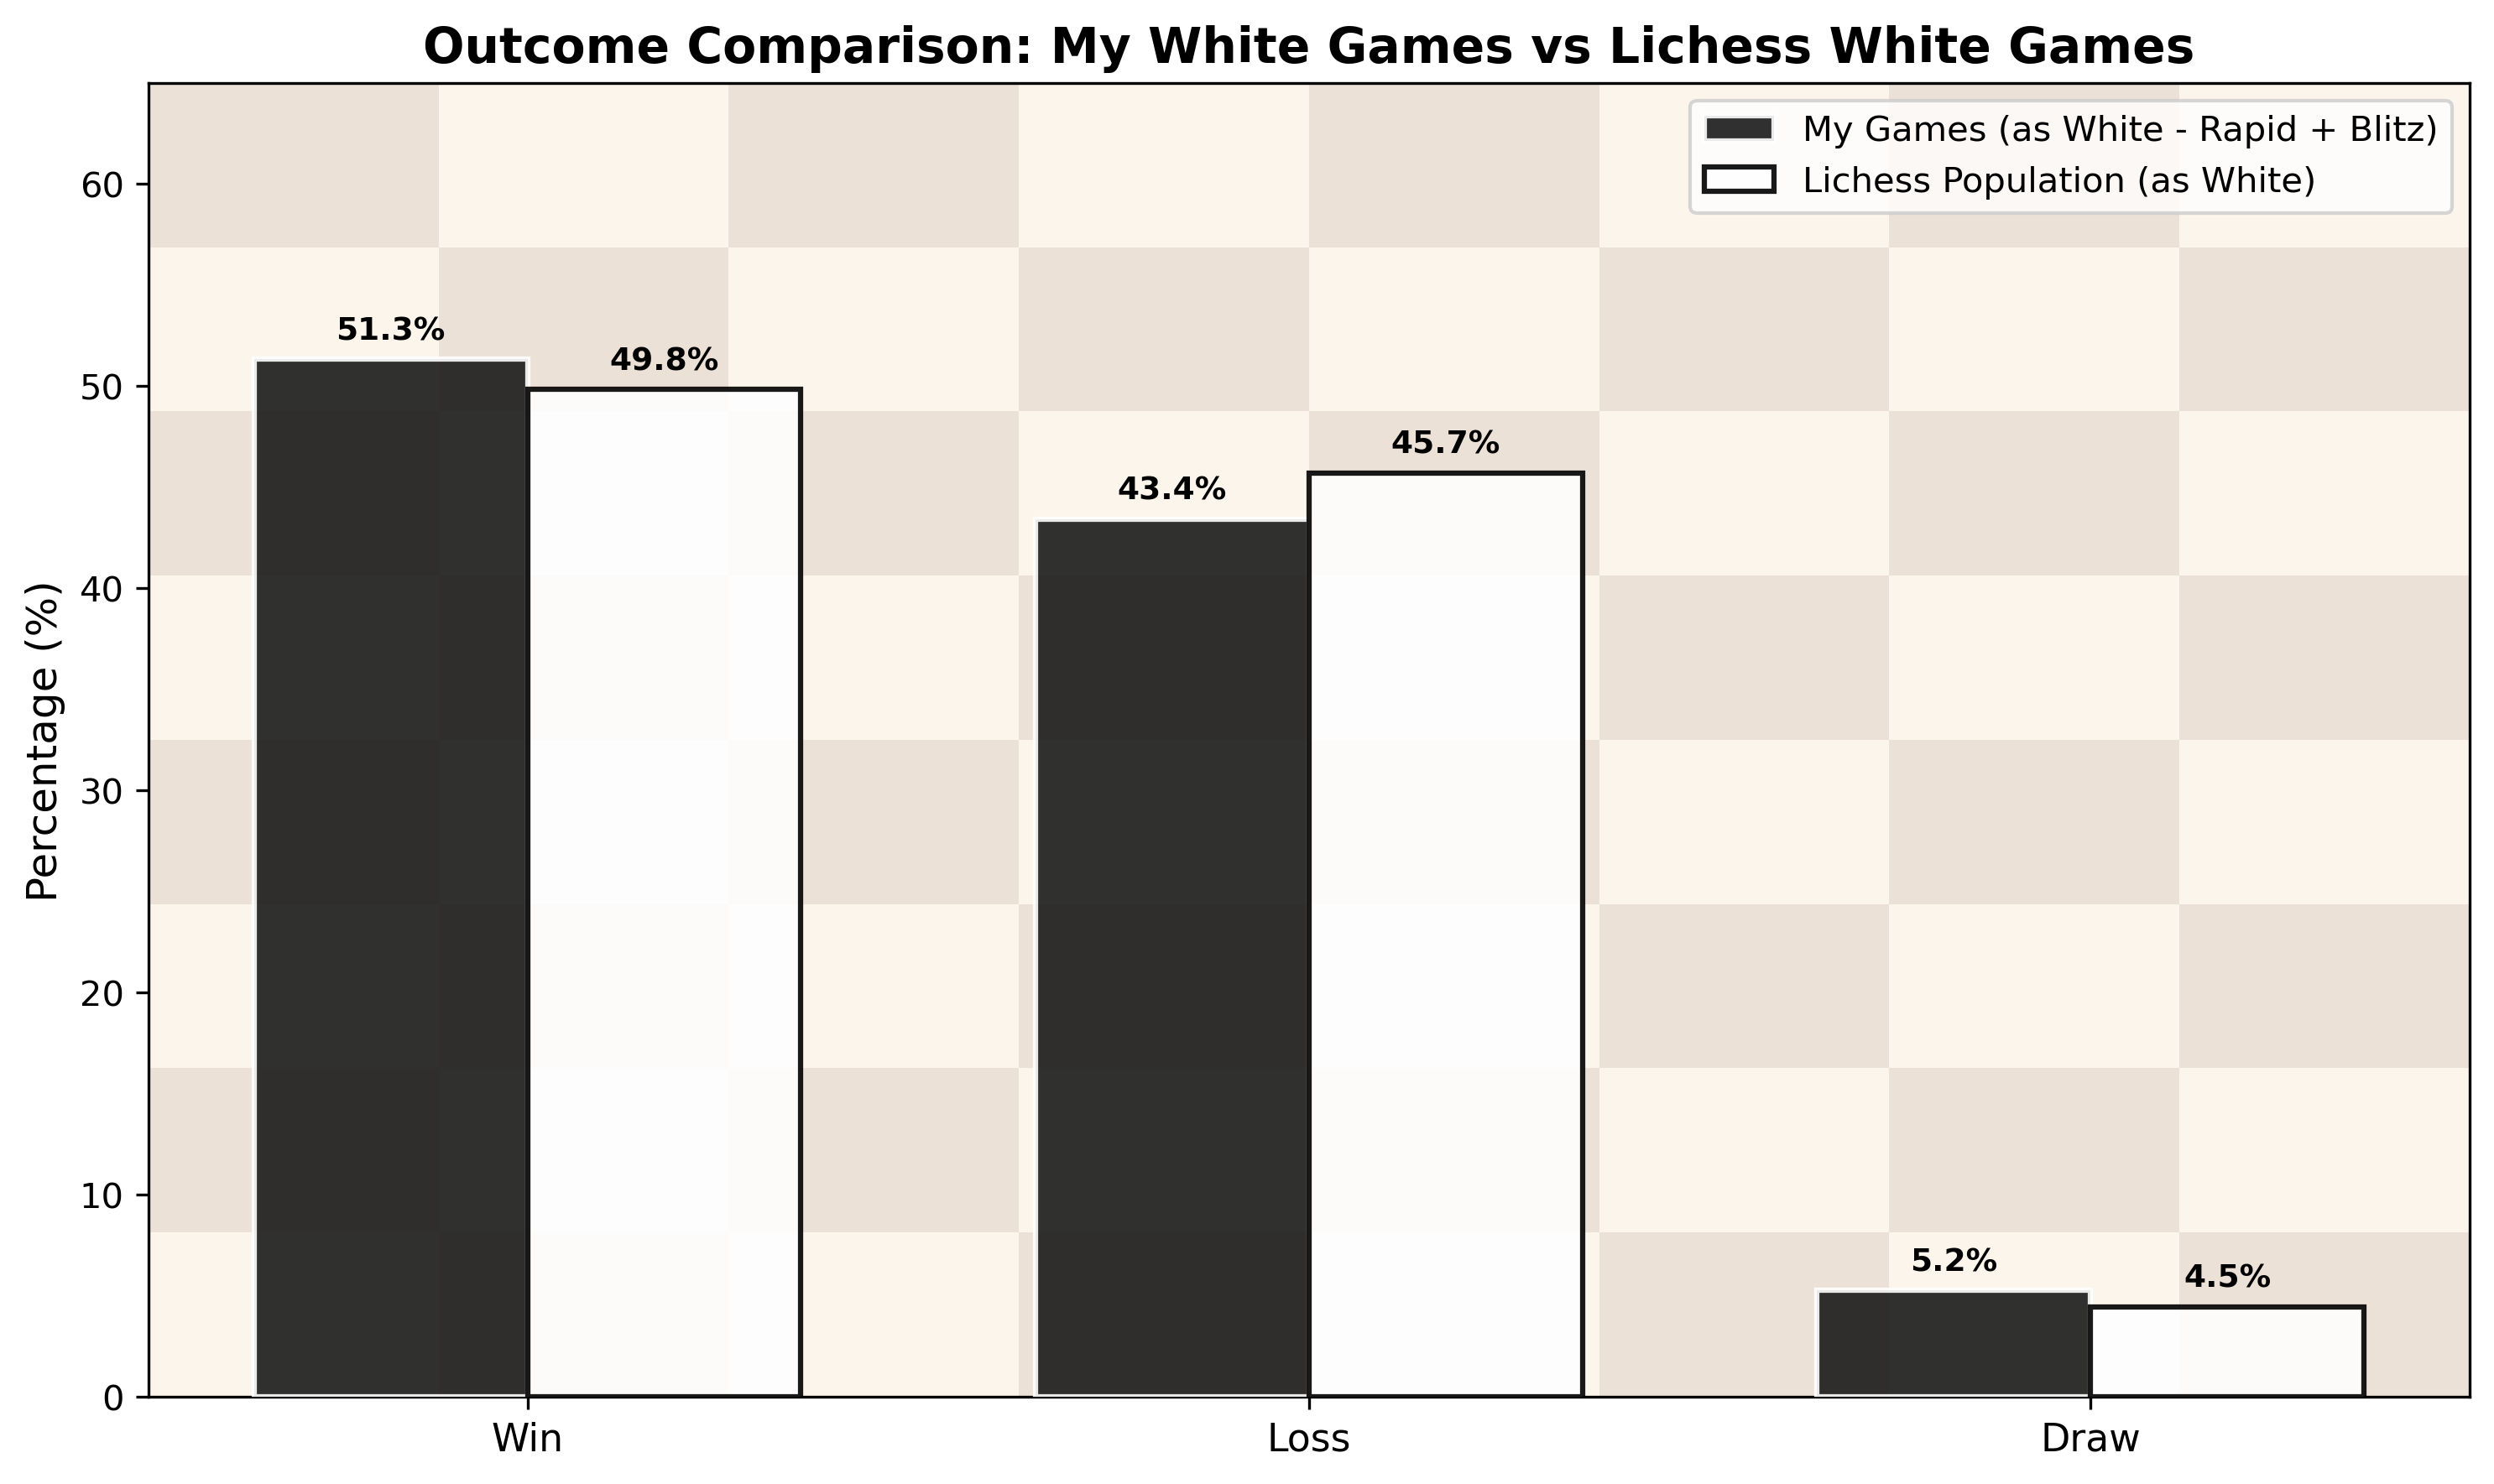

In [4]:
from IPython.display import Image
Image('fig1_comparison.png')

## Summary Statistics

Figure 1 compares outcomes specifically when playing as White to ensure a fair comparison between the two datasets. Draws are relatively rare in both datasets, which will be used to justify simplifying the outcome to a binary win/loss classification for modelling purposes. This simplification is a limitation of our analysis since draws are not strategically equivalent to losses and can happen between closely matched players. However, given their low frequency, the impact on the analysis is likely to be minimal.

My win and loss rates suggest I perform marginally better than the average Lichess player with White. This is primarily due to the nature of my rating improvement over time; as my rating increased from roughly 600 to 2000, periods of rating increase are characterised by better performance inflating the overall win rate relative to the cross-sectional Lichess population where ratings are stable. Through my chess career as White, I specialised in a single opening – the London (1000-1400) and now the English (1400-2048). My consistent opening repertoire allows me to reach better and more familiar positions out of the opening, increasing my likelihood to win. Since I became more proficient in my opening techniques over time, this can also explain the contrast to the Lichess dataset that captures many different individuals at different stages of their opening development.

## Exploring the Relationship

Figures 2 and 3 plot win probability against rating difference for my personal data and the Lichess population respectively, with games grouped into bins and a line of best fit drawn through the observed win rates. Before examining the figures, it is important to understand the structural differences between the two datasets. The standard deviation of the Lichess dataset is nearly 3 times larger than my personal dataset (218.6 compared to 75.4). Furthermore, 50% of my games are played within ±25 rating points of my opponent and 96% within ±100 points, compared to 16.9% and 49% in the Lichess data. This is due to Chess.com's matchmaking system which pairs closely rated players. This emphasises a key structural issue with my personal dataset: there is very limited data for outcomes with extreme rating differences.

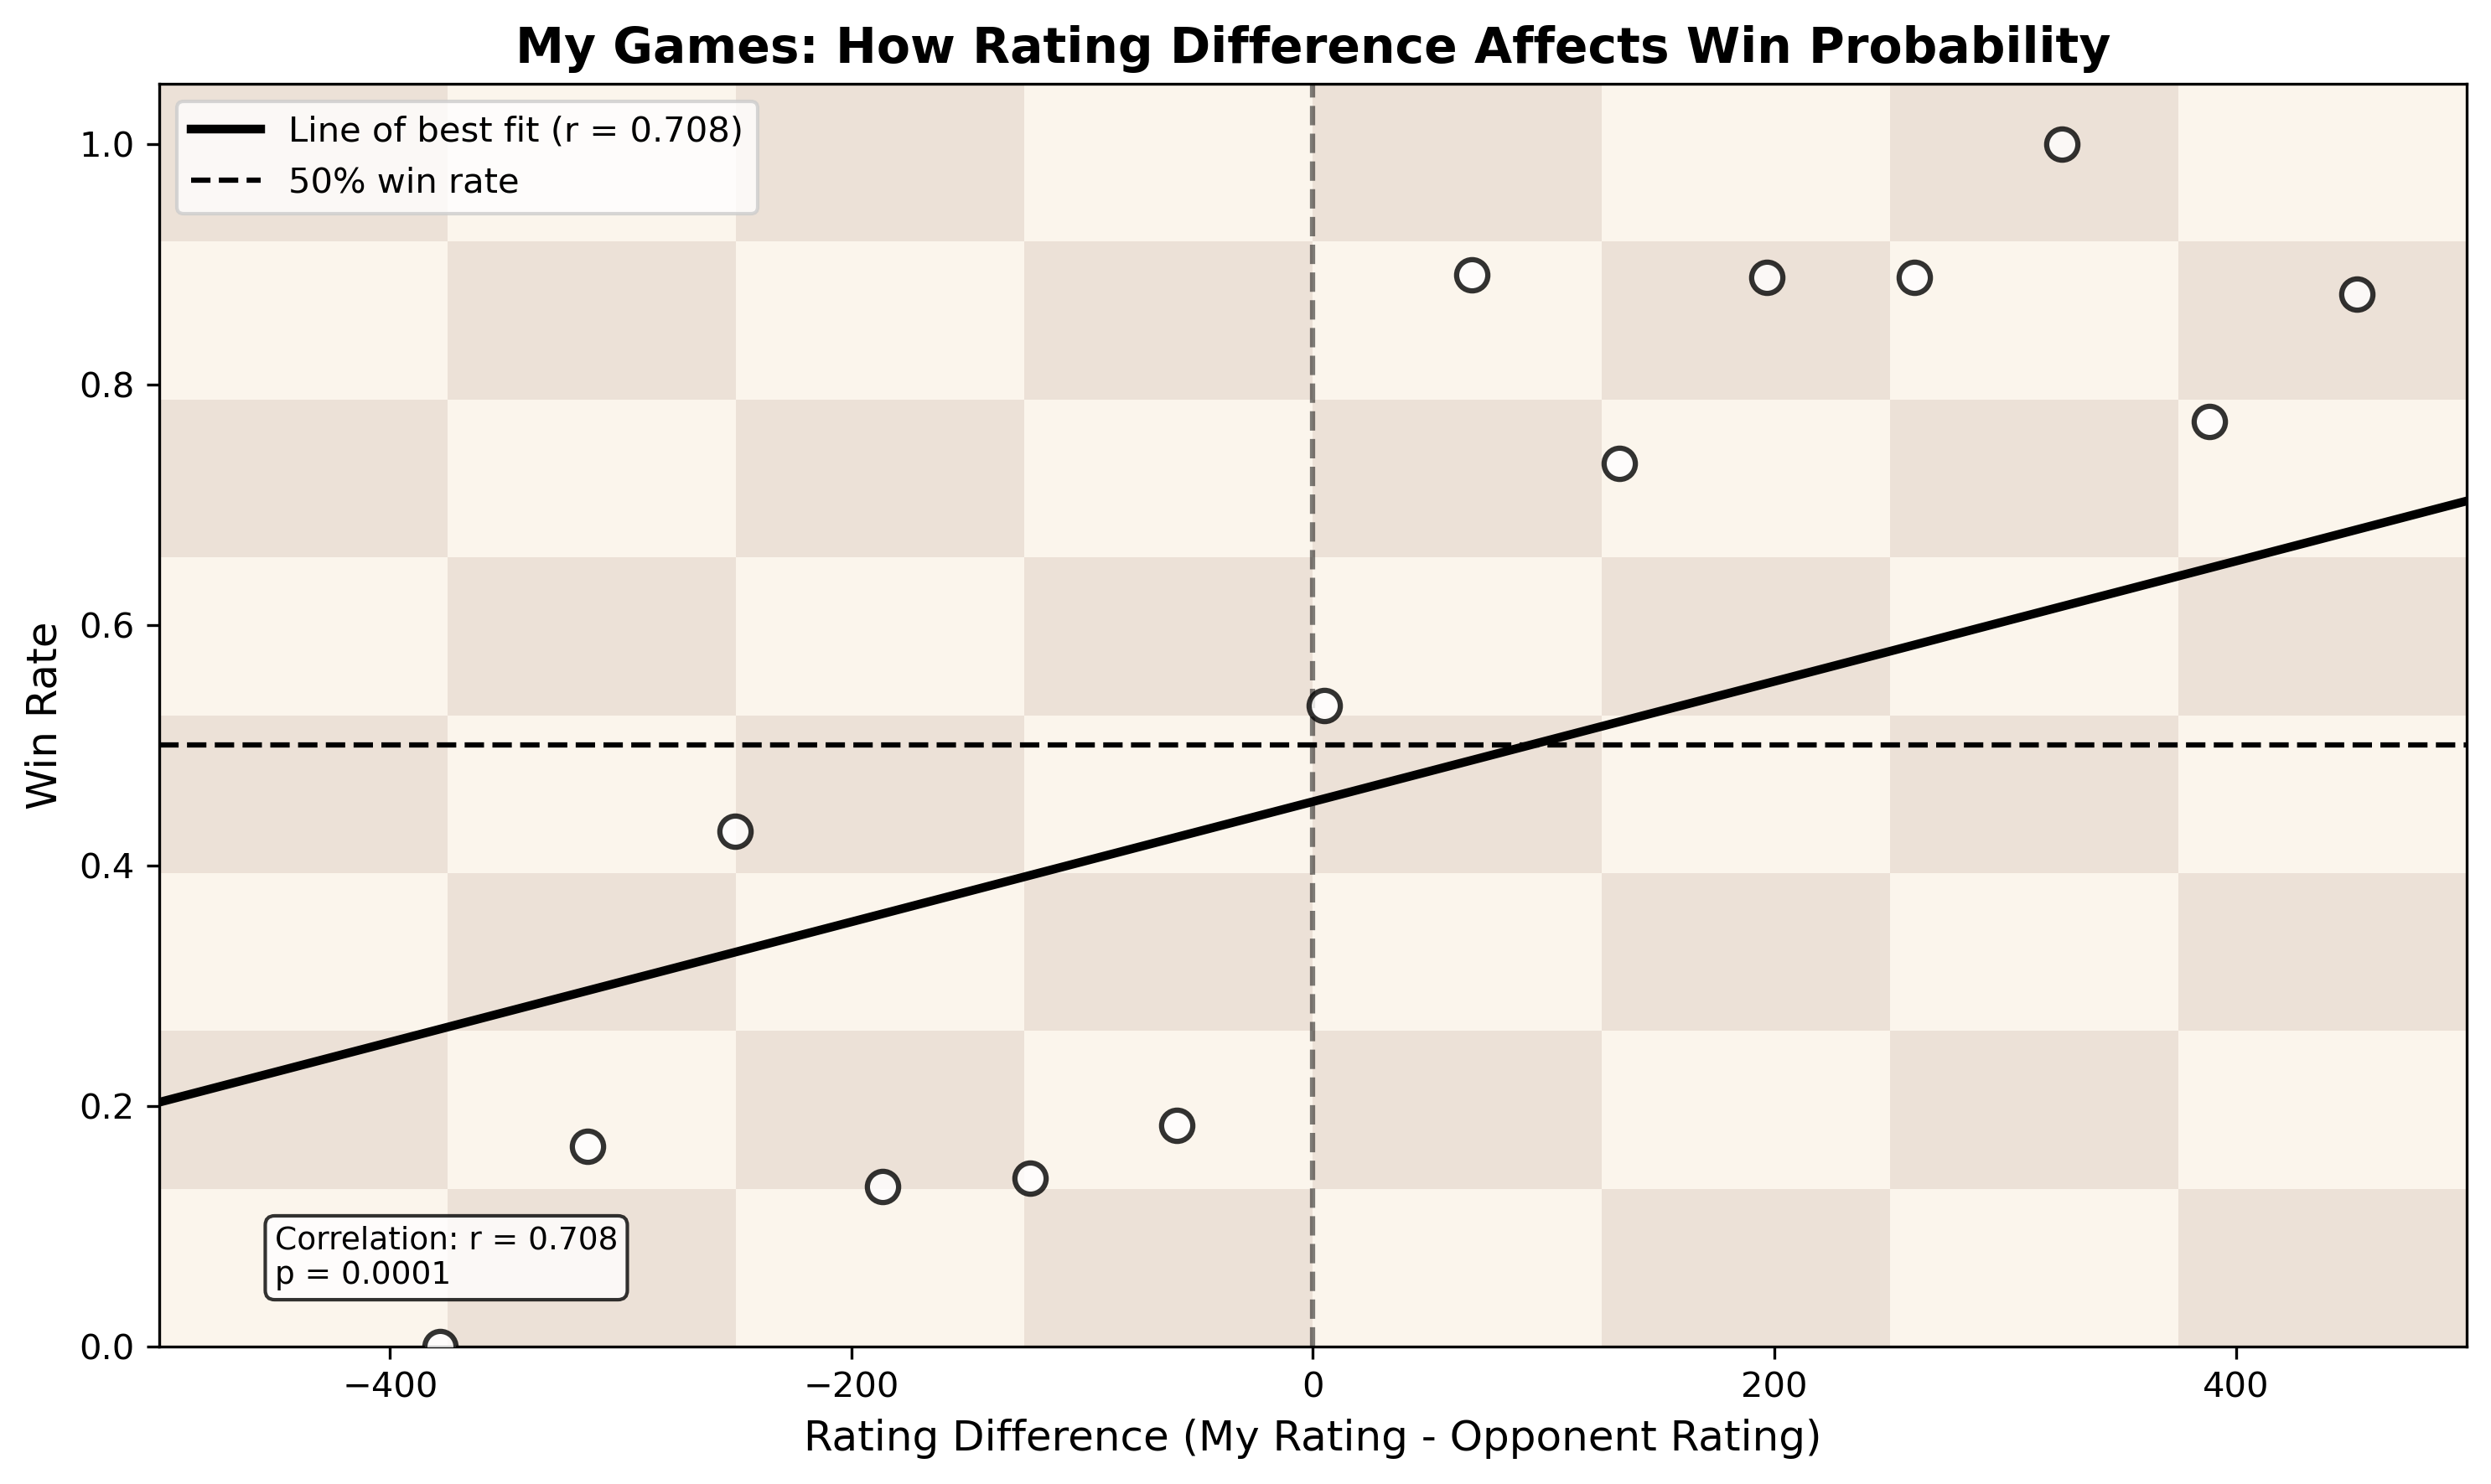

In [7]:
Image('fig2_my_win_probability.png')

Figure 2 demonstrates a strong positive relationship between rating difference and win probability, with a correlation coefficient of r = 0.708. There is visible scatter, particularly in the positive rating difference range where there are multiple bins well above the trend line. This is because there are very few observations at the extreme levels of rating differences, leading to high variances in the data. Nevertheless, Figure 2 provides a useful insight: even at the individual level, there is a strong positive relationship that still stands.

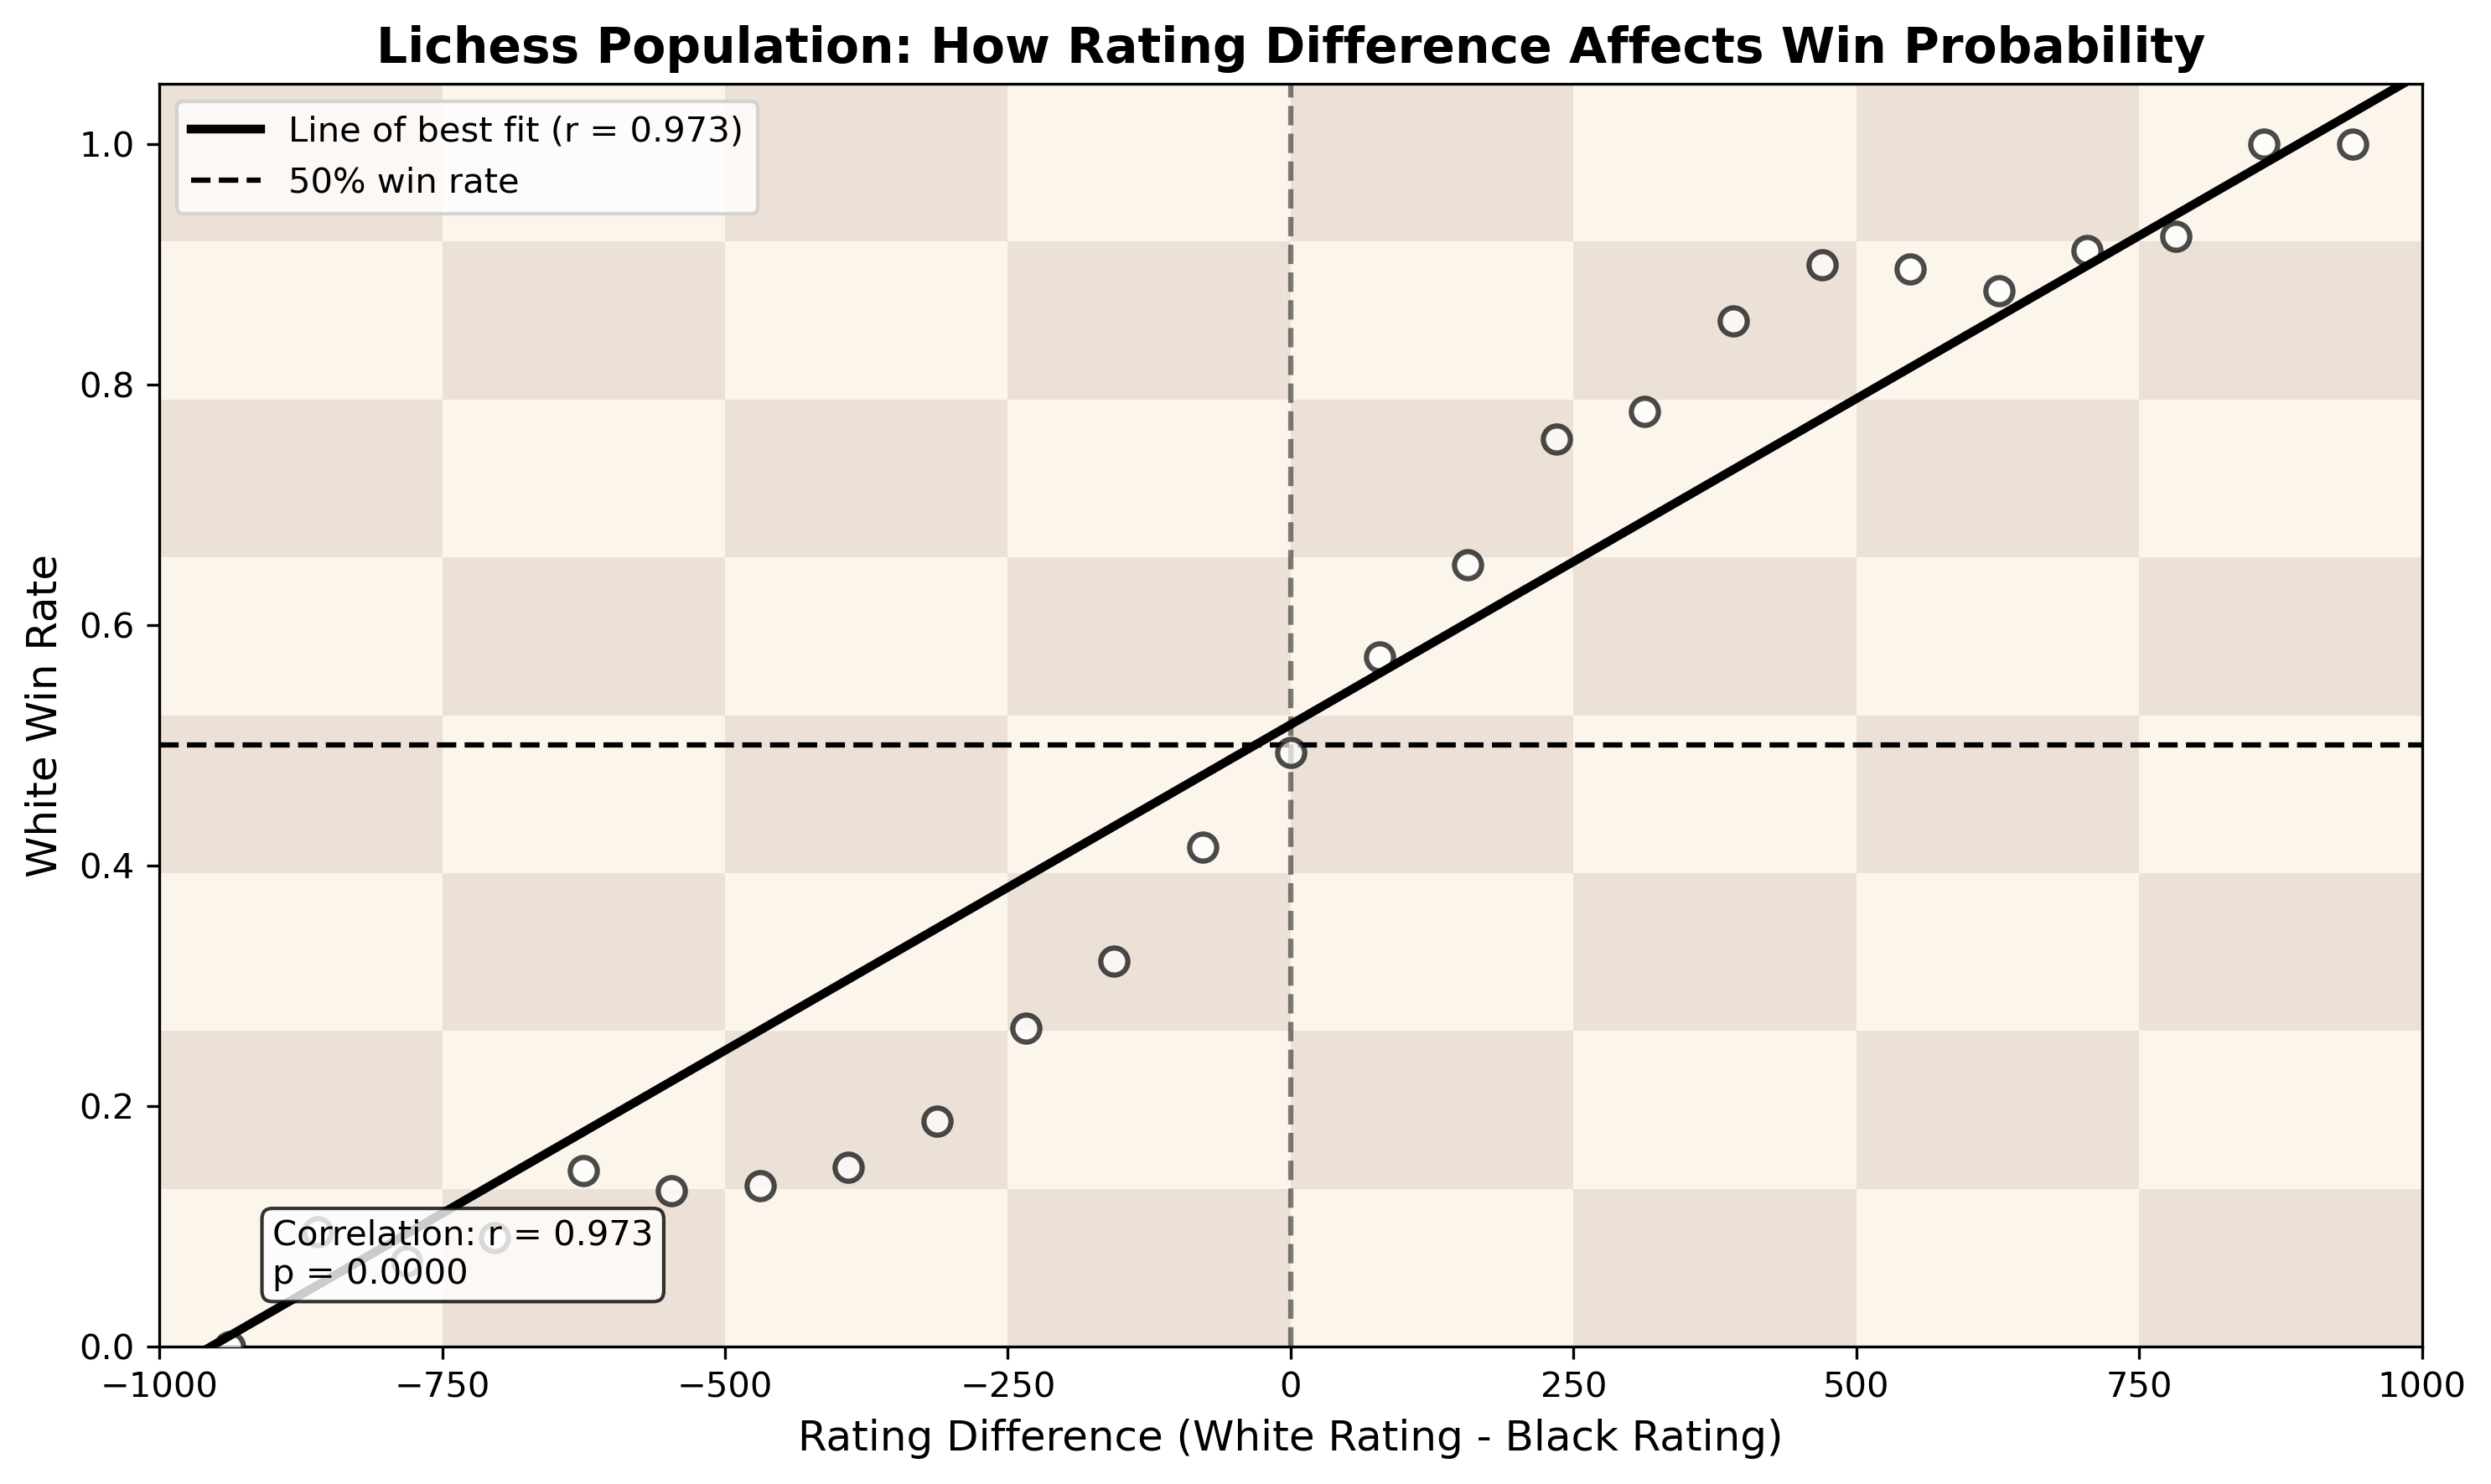

In [9]:
Image('fig3_lichess_win_probability.png')

Figure 3 shows an almost perfect linear relationship between win probability and rating difference with r = 0.973. The population data has a much greater sample size, with over 10,000 more entries. This reduction in data variance translates to the stronger correlation and improvement in the r coefficient. Importantly, the Lichess dataset populates every bin along the curve with sufficient observations which provides much more reliable win estimates than my personal data. Therefore, in Figure 3 the noise has reduced and we can confidently identify the positive relationship between our variables.

## Quantifying the Effect: Logistic Regression

Figures 2 and 3 illustrate the relationship effectively, albeit correlation alone is insufficient to draw reliable conclusions. We have not yet been able to produce any statistical tests or generate predictions beyond our observed data. To address these issues, I ran a logistic regression to model the log-odds of winning as a function of rating difference.

Since 96% of my personal games fall within ±100 rating difference, an econometric model fitted on my personal data would have to extrapolate well beyond observed data, producing unreliable estimates. For this reason, I have decided to run a logistic regression solely on the larger Lichess population which provides smoother estimates and more reliable statistical inferences.

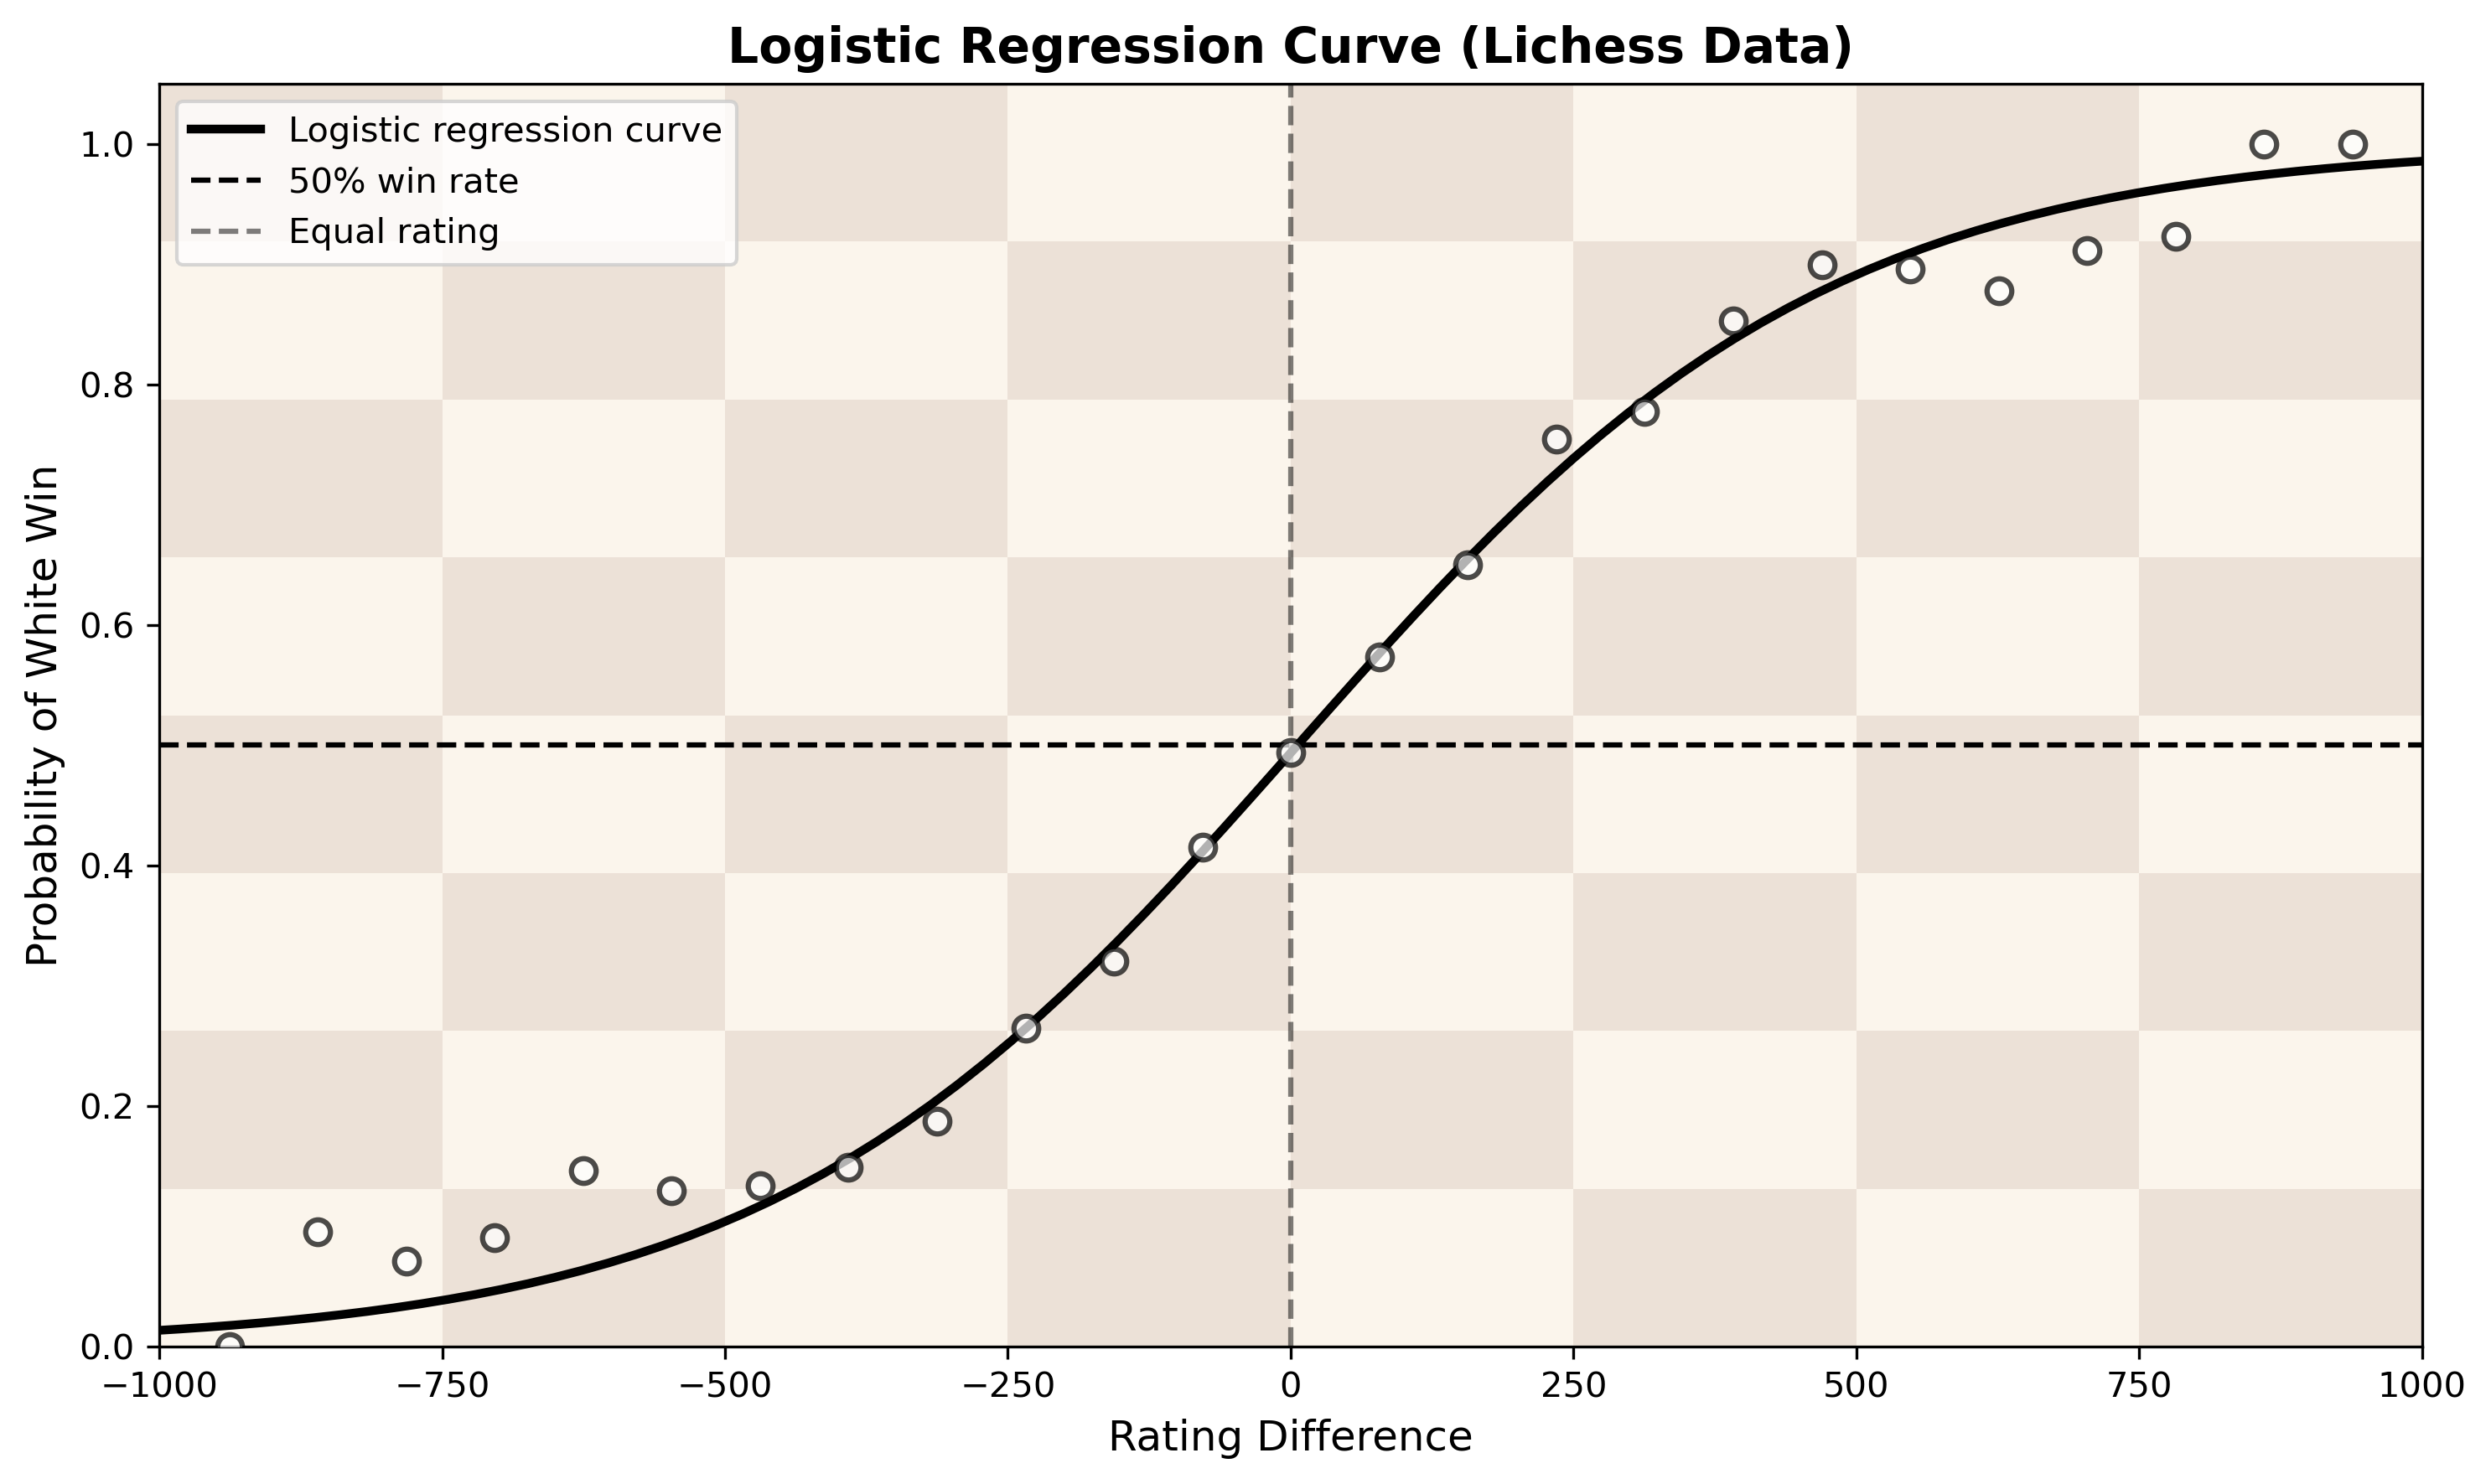

In [12]:
Image('fig4_logistic_curve_lichess.png')

The S-shaped curve in Figure 4 steepens around the point of equal ratings and flattens at the extremes. This reveals that the effect of rating difference is not uniform - at large positive differences the curve approaches 1, demonstrating that wins become near certain, while at large negative differences it approaches 0, making wins extremely unlikely. The observed win rate bins track the curve closely, indicating that the model captures the relationship well.

The estimated coefficient on rating difference is 0.0043, meaning that a 100-point rating advantage increases the log-odds of winning by 0.43. Converting this into probabilities using the logistic function, this corresponds to a win probability of 60% for the player with the 100-point advantage, compared to 49.4% when ratings are equal. This demonstrates that a modest rating advantage holds a meaningful edge and closely aligns with the official Elo prediction of 64%. We can also convert the probability at a 500-point advantage to 89.3%. This illustrates that whilst moderate rating differences still hold uncertainty, larger rating gaps make results heavily skewed. Nevertheless, results are still not 100% certain and both players always have a chance.

The z-statistic of 41.85 indicates an extremely high level of statistical significance, strongly rejecting the null hypothesis that rating difference has no effect on outcomes. The McFadden Pseudo R-squared of 0.1072 portrays a reasonable model fit.

In [14]:
from IPython.display import IFrame, display
import base64

with open('calculator.html', 'r') as f:
    html_content = f.read()

encoded = base64.b64encode(html_content.encode()).decode()
display(IFrame(src=f'data:text/html;base64,{encoded}', width='100%', height=400))

I have implemented a win probability calculator using the rating coefficient of 0.0043. Interestingly, at equal ratings the model predicts a win probability of 49.4% for White which contradicts White's first-move advantage. White is expected to win slightly more than 50% of games between equally rated players. This result is driven by the earlier stated simplification of treating draws as non-wins which mechanically pulls the baseline prediction below 50% when players are equally rated. Nevertheless, given the low frequency of draw rates, this limitation has a minor effect on overall analysis; the binary simplification remains necessary to run our logistic regression.

## Model Evaluation: ROC Curve

The ROC curve plots the true positive rate against the false positive rate across all possible classification thresholds. It illustrates the model's ability to distinguish between wins and losses.

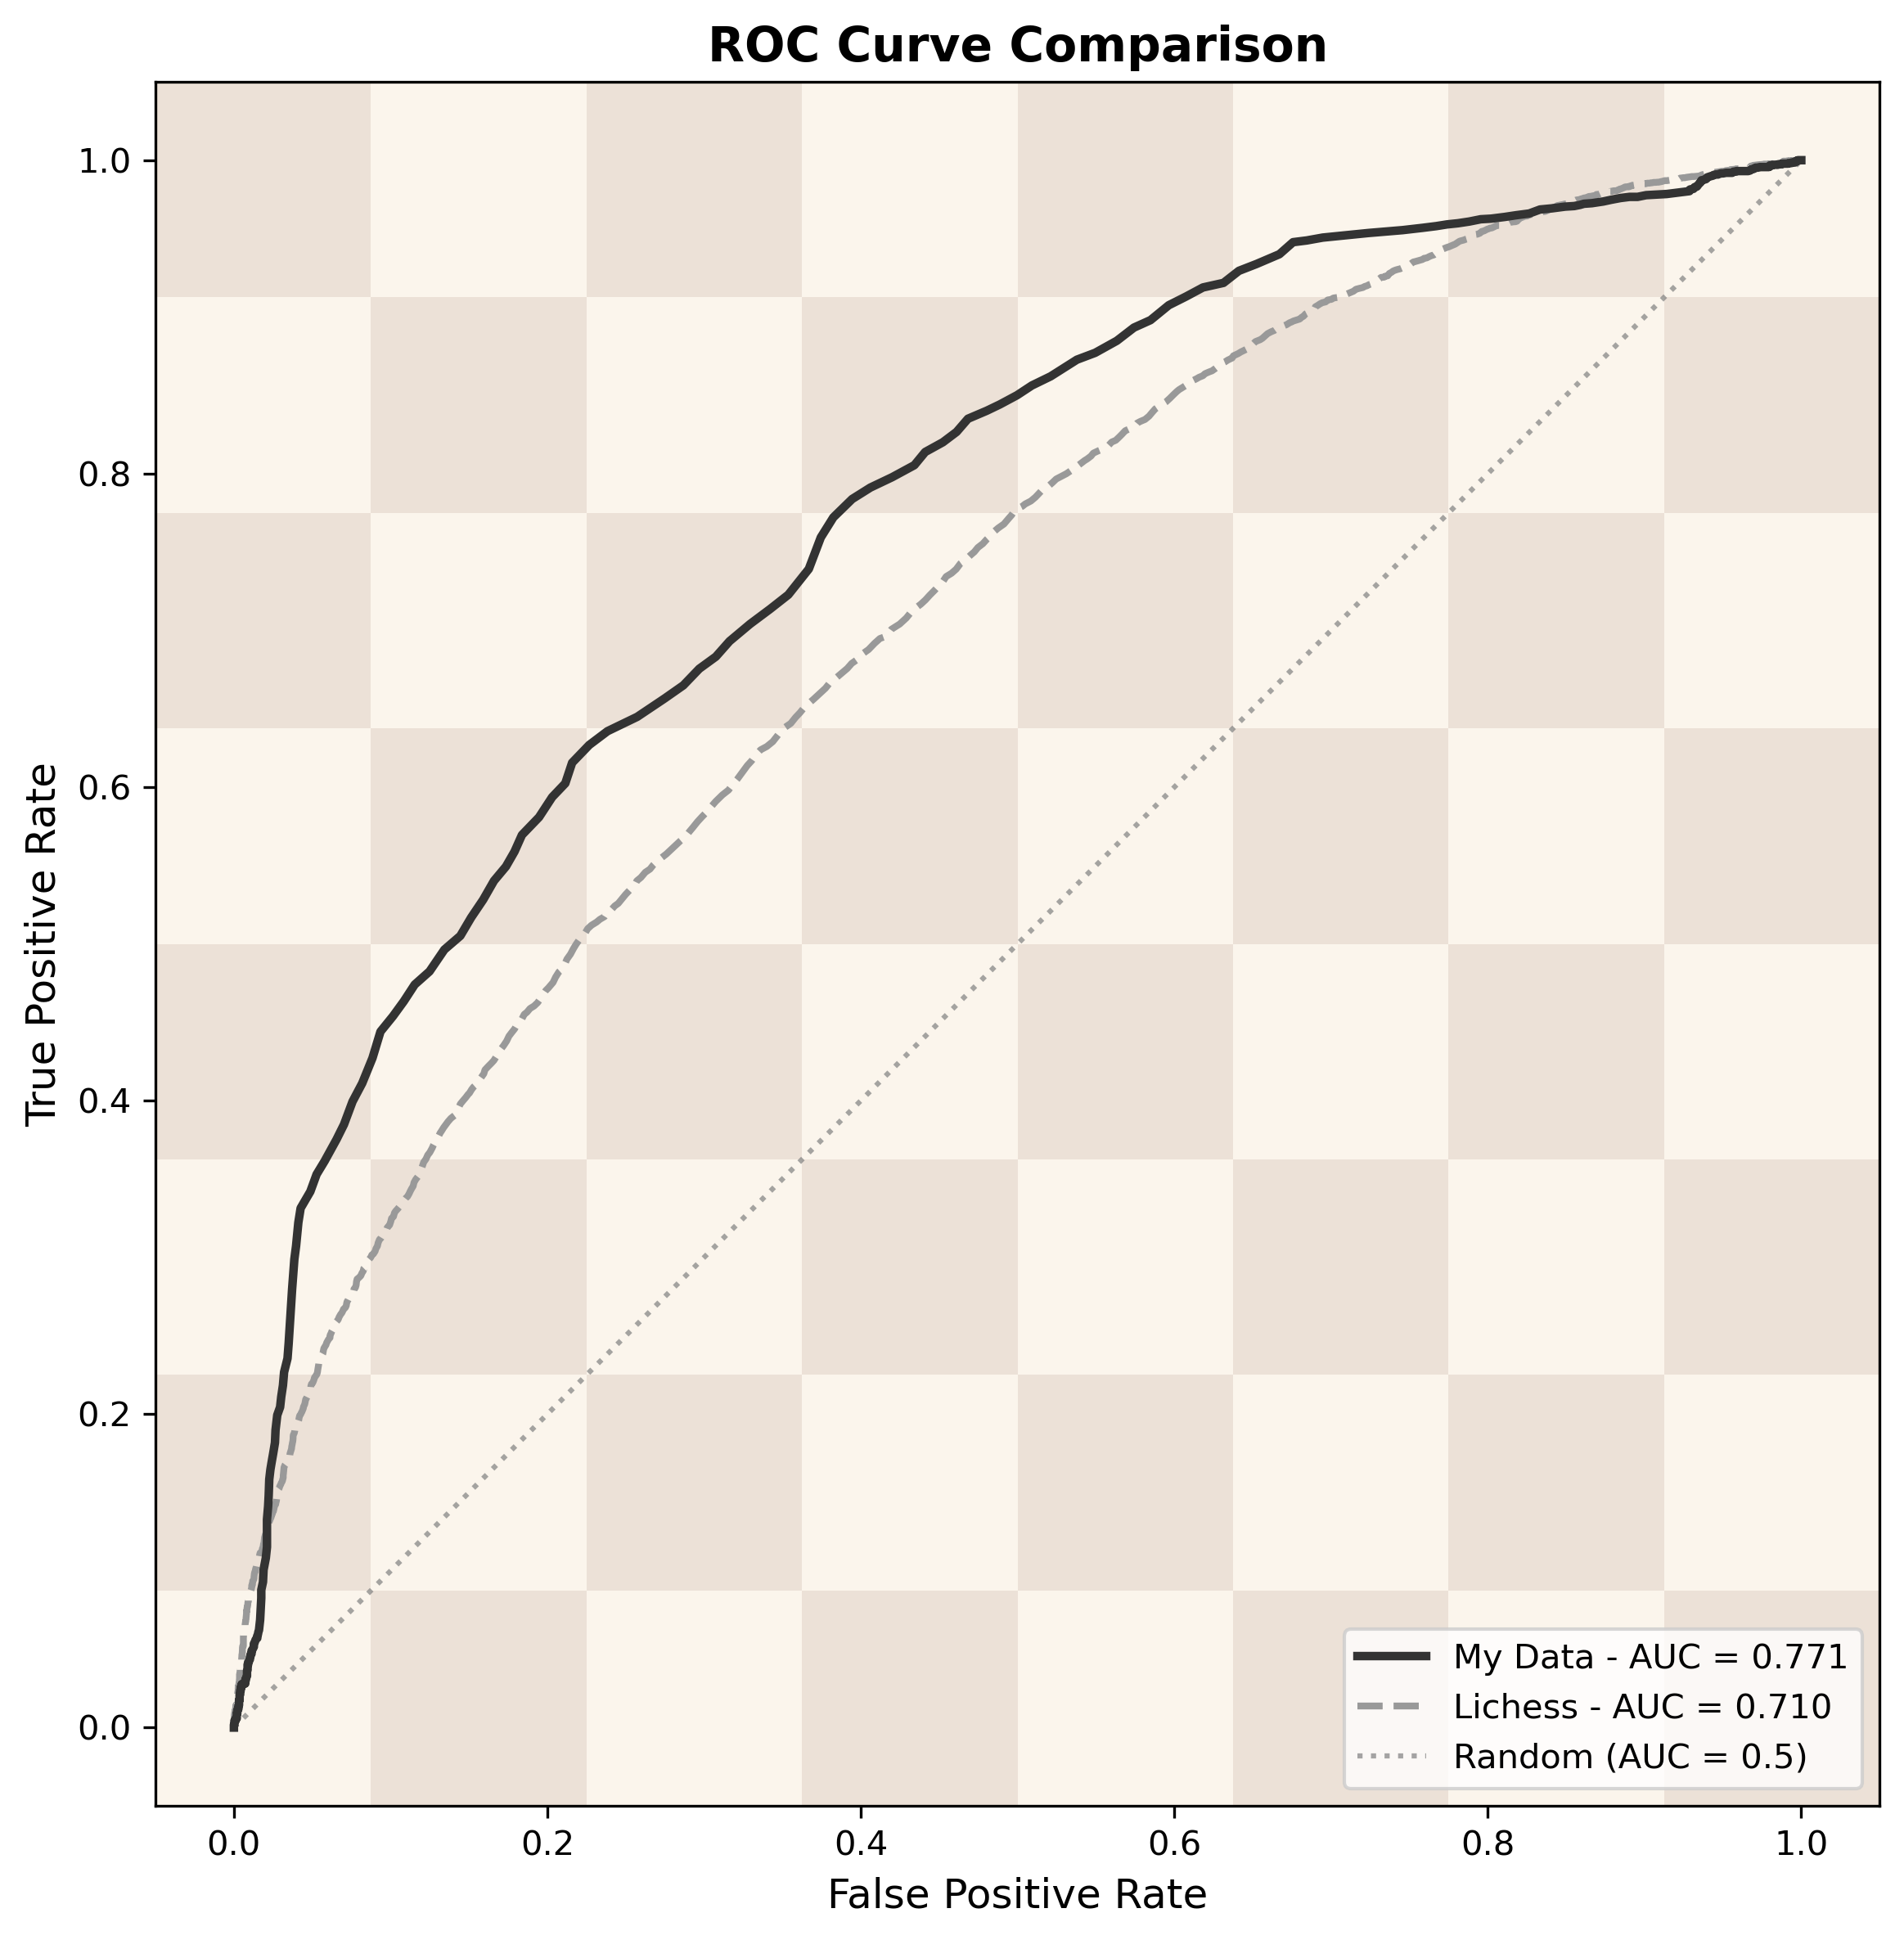

In [17]:
Image('fig5_roc_comparison.png')

The Lichess model achieves an Area Under the Curve (AUC) of 0.71. This means that when comparing a randomly selected win and a randomly selected loss, the model assigns a higher predicted probability to the correct observation approximately 71% of the time. This indicates meaningful predictive power. This places the model comfortably above random guessing (AUC = 0.5), confirming that rating difference contains substantial predictive information, while falling short of perfect classification (AUC = 1.0), confirming that outcomes are not fully determined by ratings alone.

For comparison, the personal data model achieves a higher AUC of 0.771. This reflects stronger predictive performance within the dataset, however it does not imply that this model is superior. My dataset consists mainly of closely matched games and, as I improved over time, I would consistently beat lower rated players to progress in rating. This artificially inflates the model's ability to predict outcomes. Therefore, the higher AUC result emphasises the different structural nature of my personal data relative to the Lichess dataset, with the Lichess AUC of 0.71 providing the more reliable result.

## Implications

Our findings, which closely match the Elo system's theoretical predictions for rating differences, confirm that ratings capture genuine skill differences that influence game outcomes. These findings have practical implications on how rating differences should be interpreted; ratings are a reliable tool for matchmaking and seeding. For example, ratings are used in the Swiss system tournament format, pairing closely rated players later on to ensure fair matchmaking.

However, our findings from the AUC curve reveal the limitations of using ratings as a predictive tool in tournament settings. Higher rated players are never guaranteed to win — for instance our model suggests a 100-point advantage could lead to a loss 40% of the time. This is encouraging for lower rated players as the data demonstrates a prevalent chance for upsets to occur at all levels. On the other hand, this serves as a reminder for higher rated players to always remain diligent against weaker opponents as one blunder could always lose the game.

## Conclusion

In conclusion, rating differences are a strong and reliable predictor of chess game outcomes. The analysis confirms that higher rated players are consistently more likely to win, and that this effect becomes increasingly pronounced as rating gaps grow larger. Therefore, the Elo system's ratings effectively capture differences in player strength.

On the other hand, ratings cannot fully determine the result of any individual game. Chess retains a meaningful level of unpredictability that no model based on ratings alone can eliminate — upsets are not anomalies, they are a structural feature of the game.

Nevertheless, this uncertainty is precisely what makes chess compelling. Every game carries genuine meaning, regardless of the rating gap on paper. For any chess player, the data offers a precise answer to what a rating difference actually implies; chess results are never predetermined.